# Efficient frontiers: mean-variance and CRRA utility

## Introduction

We construct two portfolio frontiers from the same set of five hypothetical but realistic asset classes by specifying expected returns, volatilities, and pairwise correlations, which together define the mean vector and covariance matrix of returns.

The mean-variance efficient frontier is then obtained in the standard Markowitz **mean-variance** framework by solving a sequence of long-only, fully invested portfolio optimization problems, such that weights are constrained to sum to one and cannot be negative. This frontier depends only on first and second moments of returns and therefore abstracts from higher-order features such as skewness and kurtosis. By contrast, the constant relative risk aversion (CRRA) utility frontier is built by solving for portfolios that maximize expected **CRRA utility** over terminal wealth for different values of the risk-aversion parameter $\gamma$.

To do so, we approximate expected utility by simulation: in the baseline case, asset returns are modeled as jointly **normally distributed**. In the extended version (see questions at the bottom), returns can be generated from a **non-normal multivariate** process with skewness and fat tails. The resulting comparison highlights a key methodological difference: the mean-variance frontier is entirely moment-based, whereas the CRRA frontier depends on the full assumed return distribution, so higher moments and tail behavior can affect the location of the optimal portfolios even when expected returns and covariances are held fixed.


## Exercise

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
# Inputs - 5 hypothetical assets:

assets = ["US Equity", "Intl Equity", "US Bonds", "REITs", "Commodities"]

exp_ret = np.array([0.085, 0.078, 0.040, 0.065, 0.055])   # annual expected returns
vols = np.array([0.16, 0.18, 0.06, 0.14, 0.20])               # annual volatilities

corr = np.array([[1.00, 0.82, 0.10, 0.65, 0.35],
                 [0.82, 1.00, 0.05, 0.58, 0.40],
                 [0.10, 0.05, 1.00, 0.15, 0.00],
                 [0.65, 0.58, 0.15, 1.00, 0.30],
                 [0.35, 0.40, 0.00, 0.30, 1.00]])

cov = np.diag(vols) @ corr @ np.diag(vols)

assets_df = pd.DataFrame({
    "Asset": assets,
    "Expected Return": exp_ret,
    "Volatility": vols})

corr_df = pd.DataFrame(corr, index=assets, columns=assets)
cov_df = pd.DataFrame(cov, index=assets, columns=assets)

In [3]:
cov_df

,US Equity,Intl Equity,US Bonds,REITs,Commodities
US Equity,0.025600,0.023616,0.00096,0.014560,0.0112
Intl Equity,0.023616,0.032400,0.00054,0.014616,0.0144
US Bonds,0.000960,0.000540,0.00360,0.001260,0.0000
REITs,0.014560,0.014616,0.00126,0.019600,0.0084
Commodities,0.011200,0.014400,0.00000,0.008400,0.0400


In [5]:
# Set constraints:

n = len(assets)
bounds = [(0.0, 1.0)] * n # long only

def budget_constraint(w):
    return np.sum(w) - 1

base_cons = [{"type": "eq", "fun": budget_constraint}] # fully invested

In [6]:
# Define objective and mimimization:

def portfolio_stats(w, mu, sigma):
    ret_port = w @ mu
    vol_port = np.sqrt(w @ sigma @ w)
    return ret_port, vol_port

def mv_for_target(target_return):
    x0 = np.repeat(1/n, n)
    constraints = base_cons + [{"type": "eq", "fun": lambda w, tr=target_return: w @ exp_ret - tr}]
    res = minimize(
        lambda w: w @ cov @ w, 
        x0=x0, 
        method="SLSQP", 
        bounds=bounds, 
        constraints=constraints)
    if not res.success:
        return None
    return res.x

In [7]:
# Mean-variance efficient frontier:

target_returns = np.linspace(exp_ret.min(), exp_ret.max(), 180) # set range of target returns for mean-variance optimization
frontier = []
for tr in target_returns:
    w = mv_for_target(tr)
    if w is not None:
        ret_port, vol_port = portfolio_stats(w, exp_ret, cov)
        frontier.append([ret_port, vol_port, *w, np.sum(w)])

frontier_cols = ["Expected Return", "Volatility"] + assets + ["Sum of Weights"]
frontier_df = pd.DataFrame(frontier, columns=frontier_cols)

In [8]:
frontier_df

,Expected Return,Volatility,US Equity,Intl Equity,US Bonds,REITs,Commodities,Sum of Weights
0,0.040000,0.060000,0.000000e+00,0.000000e+00,1.000000,2.497181e-18,2.273148e-12,1.0
1,0.040251,0.059090,4.163336e-16,0.000000e+00,0.983240,0.000000e+00,1.675977e-02,1.0
2,0.040503,0.058375,1.665335e-16,0.000000e+00,0.966480,2.220446e-16,3.351955e-02,1.0
3,0.040754,0.057864,2.775558e-17,1.110223e-16,0.949721,2.775558e-17,5.027932e-02,1.0
4,0.041006,0.057561,2.775558e-17,1.110223e-16,0.932961,0.000000e+00,6.703910e-02,1.0
...,...,...,...,...,...,...,...,...
175,0.083994,0.156561,9.715062e-01,0.000000e+00,0.017428,1.106538e-02,2.168404e-17,1.0
176,0.084246,0.157419,9.789418e-01,0.000000e+00,0.013321,7.737078e-03,8.673617e-19,1.0
177,0.084497,0.158279,9.859421e-01,6.938894e-18,0.008865,5.192482e-03,8.673617e-19,1.0
178,0.084749,0.159139,9.928118e-01,1.561251e-17,0.004305,2.882870e-03,4.336809e-19,1.0


In [9]:
# CRRA optimal portfolios:

rng = np.random.default_rng(7) # create random number generator with seed 7
n_sims = 100000
sim_rets = rng.multivariate_normal(exp_ret, cov, size=n_sims) # simulate returns as normally distributed
sim_rets = np.clip(sim_rets, -0.99, None) # replace any return below -0.99 with -0.99

gammas = np.array([2, 3, 5, 7, 10, 15, 20, 30, 50]) # define set of risk aversions

def crra_utility(w, gamma):
    ret_p = sim_rets @ w
    wealth = 1 + ret_p # single period problem
    util = (wealth ** (1 - gamma)) / (1 - gamma)
    exp_util = np.mean(util)
    return exp_util

crra_rows = []
for gamma in gammas:
    x0 = np.repeat(1/n, n)
    res = minimize(
        lambda w, g=gamma: -crra_utility(w, gamma),
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=base_cons,
        options={"maxiter": 500})
    w = res.x
    ret_crra, vol_crra = portfolio_stats(w, exp_ret, cov)
    crra_rows.append([gamma, ret_crra, vol_crra, *w, np.sum(w)])

crra_cols = ["Risk Aversion (gamma)", "Expected Return", "Volatility"] + assets +["Sum of Weights"]
crra_df = pd.DataFrame(crra_rows, columns=crra_cols)

In [11]:
crra_df

,Risk Aversion (gamma),Expected Return,Volatility,US Equity,Intl Equity,US Bonds,REITs,Commodities,Sum of Weights
0,2,0.081679,0.148705,0.908821,3.469447e-18,0.059915,0.031265,6.613633e-18,1.0
1,3,0.069420,0.108618,0.630569,0.000000e+00,0.327665,0.041767,1.734723e-18,1.0
2,5,0.059080,0.078940,0.395330,5.421011e-20,0.548615,0.044916,1.113858e-02,1.0
3,7,0.054811,0.068974,0.291104,0.000000e+00,0.631121,0.054425,2.334960e-02,1.0
4,10,0.051425,0.062680,0.213032,0.000000e+00,0.699952,0.053324,3.369183e-02,1.0
5,15,0.048886,0.059210,0.154022,0.000000e+00,0.751549,0.053830,4.059923e-02,1.0
6,20,0.047470,0.057821,0.116550,7.971652e-03,0.781110,0.050668,4.370053e-02,1.0
7,30,0.046217,0.056955,0.083562,1.327630e-02,0.807896,0.052288,4.297875e-02,1.0
8,50,0.045622,0.056726,0.070584,1.970998e-02,0.827477,0.046351,3.587777e-02,1.0


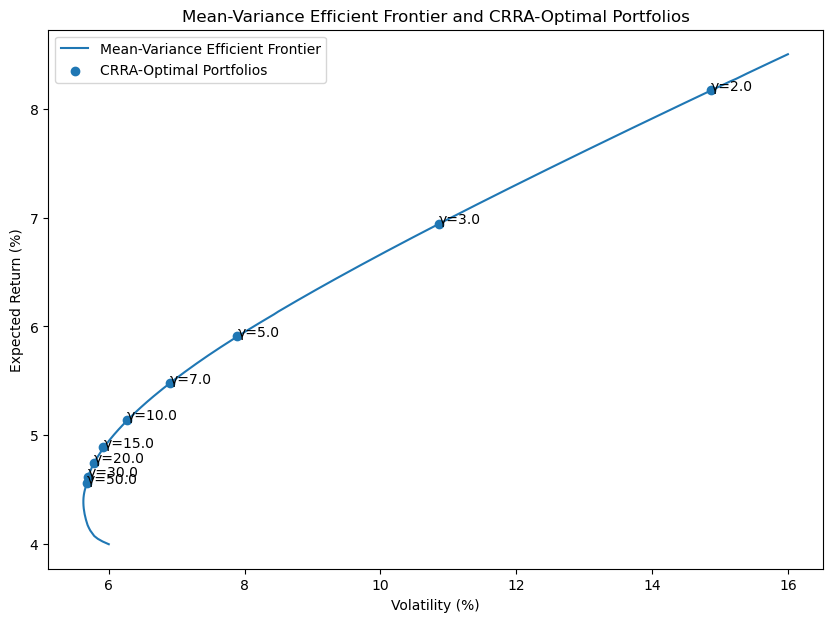

In [12]:
# Plot charts:

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(frontier_df["Volatility"] * 100, frontier_df["Expected Return"] * 100, label="Mean-Variance Efficient Frontier")
ax.scatter(crra_df["Volatility"] * 100, crra_df["Expected Return"] * 100, label="CRRA-Optimal Portfolios")

ax.set_title("Mean-Variance Efficient Frontier and CRRA-Optimal Portfolios")
ax.set_xlabel("Volatility (%)")
ax.set_ylabel("Expected Return (%)")
ax.legend()

for _, row in crra_df.iterrows():
    gamma = row["Risk Aversion (gamma)"]
    x = row["Volatility"] * 100
    y = row["Expected Return"] * 100
    ax.annotate(f"γ={gamma:.1f}",(x, y))

plt.show()

## Time for you to try

Now that you have experimented, you should be able to apply the approaches above to do the following:

1) Model the asset returns using a multivariate non-normal distribution that allows for skewness and kurtosis. How do the resulting optimal portfolios compare with those obtained under a multivariate normal distribution?

2) Use a quadratic utility ($U(W)=W-(1/2)\gamma W^2$) instead of CRRA and compute the new optimal portfolios. What do you notice? Why?